In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import scipy.stats as stats

In [4]:
data = pd.read_csv('final_final_data.csv')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101763 entries, 0 to 101762
Data columns (total 37 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Unnamed: 0                101763 non-null  int64 
 1   encounter_id              101763 non-null  int64 
 2   patient_nbr               101763 non-null  int64 
 3   race                      99492 non-null   object
 4   gender                    101763 non-null  object
 5   age                       101763 non-null  object
 6   admission_type_id         101763 non-null  int64 
 7   discharge_disposition_id  101763 non-null  int64 
 8   admission_source_id       101763 non-null  int64 
 9   time_in_hospital          101763 non-null  int64 
 10  num_lab_procedures        101763 non-null  int64 
 11  num_procedures            101763 non-null  int64 
 12  num_medications           101763 non-null  int64 
 13  number_outpatient         101763 non-null  int64 
 14  numb

In [6]:
data['patient_nbr'].nunique()

71515

## Метрика

Мы хотим проанализировать взаимосвязь между полом, возрастом и количестве процедур. Данный анализ поможет в проектировании помещений в больнице, чтобы учесть возможный дисбаланс в данных группах и увеличить/уменьшить кол-во процедурных кабинетов в отделениях больницы

Для данной задачи пойдет двухфакторный ANOVA - статистический тест, который основан на дисперсионном анализе внутригрупповой и междугрупповой дисперсией. Благодаря данному тесту мы сможем узнать есть ли различие между группами, на которые поделим наш датасет (пол и возраст)

https://studfile.net/preview/5855743/page:41/

Для данного анализа необходимо:
1. Независимость наблюдений
2. Гомогенность дисперсий
3. Нормальное распределение целевой переменной. При большом количестве данных достаточно симметричного распределения данных, приближенного к нормальному


Гипотеза

H0.А: Пол не влияет на количество медицинских процедур

H0.В: Возраст не влияет на количество медицинских процедур

H0.АВ: Факторы возраст и пол совместно не оказывают влияние на количество медицинский процедур



1. Для обеспечения независимости переменных мы возьмем только первое вхождение юзера в наш датасет

In [7]:
data = data.drop_duplicates(subset='patient_nbr', keep='first')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71515 entries, 0 to 101762
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                71515 non-null  int64 
 1   encounter_id              71515 non-null  int64 
 2   patient_nbr               71515 non-null  int64 
 3   race                      69569 non-null  object
 4   gender                    71515 non-null  object
 5   age                       71515 non-null  object
 6   admission_type_id         71515 non-null  int64 
 7   discharge_disposition_id  71515 non-null  int64 
 8   admission_source_id       71515 non-null  int64 
 9   time_in_hospital          71515 non-null  int64 
 10  num_lab_procedures        71515 non-null  int64 
 11  num_procedures            71515 non-null  int64 
 12  num_medications           71515 non-null  int64 
 13  number_outpatient         71515 non-null  int64 
 14  number_emergency          

Разделение факторов на градации:

У нас есть две группы: Женщины - А1, Мужчины -А2, а также люди преклонного возраста 50-70 лет - Б1 и Пожилые 70 лет и старше - Б2

градация A1Б1, A1Б2, А2Б1, А2Б2

градация правильная

(array([  154.,     0.,     0.,   535.,     0.,     0.,  1127.,     0.,
            0.,     0.,  2699.,     0.,     0.,  6878.,     0.,     0.,
        12466.,     0.,     0.,     0., 15959.,     0.,     0., 18208.,
            0.,     0., 11589.,     0.,     0.,  1900.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. , 6.3, 6.6, 6.9, 7.2, 7.5,
        7.8, 8.1, 8.4, 8.7, 9. ]),
 <BarContainer object of 30 artists>)

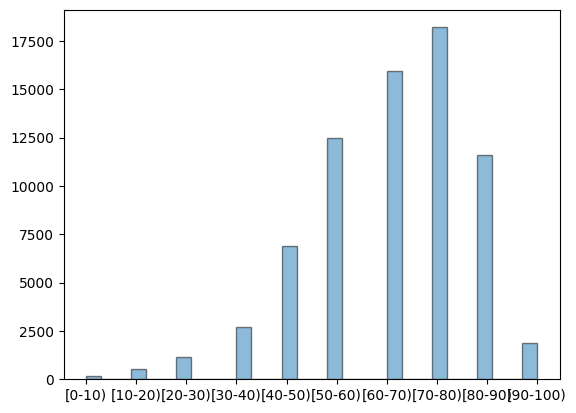

In [ ]:
plt.hist(data['age'], bins=30, edgecolor='black', alpha=0.5)

In [ ]:
data = data[~data['age'].isin(['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)'])]
q = ['[50-60)','[60-70)']
data['age_group']= np.where(data['age'].isin(q),'young','old')
data.head()

,Unnamed: 0,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,insulin,change,diabetesMed,readmitted,readmitted_30,readmitted_any,outpatient_group,emergency_group,inpatient_group,age_group
5,5,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,Steady,No,Yes,>30,0,1,0,0,0,young
6,6,84259809,Caucasian,Male,[60-70),3,1,2,4,70,...,Steady,Ch,Yes,NO,0,0,0,0,0,young
7,7,114882984,Caucasian,Male,[70-80),1,1,7,5,73,...,No,No,Yes,>30,0,1,0,0,0,old
8,8,48330783,Caucasian,Female,[80-90),2,1,4,13,68,...,Steady,Ch,Yes,NO,0,0,0,0,0,old
9,9,63555939,Caucasian,Female,[90-100),3,3,4,12,33,...,Steady,Ch,Yes,NO,0,0,0,0,0,old


По числу объекты (пациенты) распределены по градациям факторов практически равномерно, за исключением 1 группы (женщины 70 и более лет):

gender  age_group
Female  old          18153
        young        13826
Male    old          13544
        young        14599
dtype: int64
                    count       mean        std  min   25%   50%   75%    max
gender age_group                                                             
Female old        18153.0  44.046989  19.545811  1.0  32.0  45.0  58.0  109.0
       young      13826.0  42.167655  20.152266  1.0  30.0  43.5  56.0  118.0
Male   old        13544.0  43.468990  19.804805  1.0  31.0  44.0  58.0  109.0
       young      14599.0  42.658607  19.909699  1.0  31.0  43.0  56.0  121.0


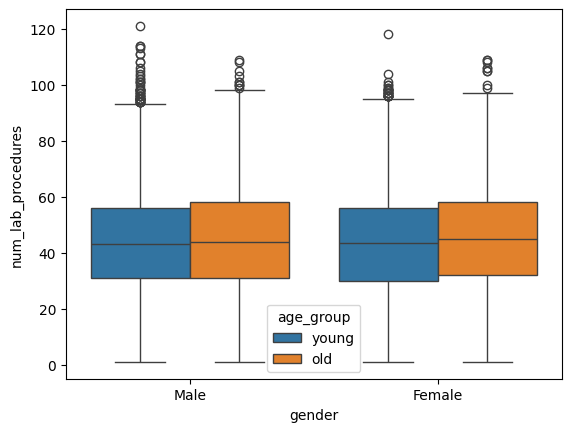

In [ ]:
print(data.groupby(['gender','age_group']).size())
print(data.groupby(['gender','age_group'])['num_lab_procedures'].describe())

sns.boxplot(data=data, x='gender', y='num_lab_procedures', hue='age_group')
plt.show()

(array([1832.,  653.,    0.,  432.,    0.,  254.,  176.,    0.,  174.,
           0.,  198.,  224.,    0.,  573.,    0.,  481.,  416.,    0.,
         303.,    0.,  255.,  226.,    0.,  233.,    0.,  307.,  405.,
           0.,  406.,  614.]),
 array([ 1. ,  1.6,  2.2,  2.8,  3.4,  4. ,  4.6,  5.2,  5.8,  6.4,  7. ,
         7.6,  8.2,  8.8,  9.4, 10. , 10.6, 11.2, 11.8, 12.4, 13. , 13.6,
        14.2, 14.8, 15.4, 16. , 16.6, 17.2, 17.8, 18.4, 19. ]),
 <BarContainer object of 30 artists>)

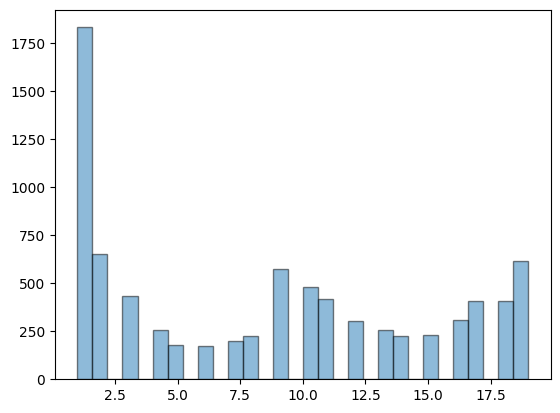

In [ ]:

plt.hist(data[data['num_lab_procedures']<20]['num_lab_procedures'], bins=30, edgecolor='black', alpha=0.5)

Мы видим сильный перекос в сторону 1 процедуры на человека. В рамках больницы это не интересное нам явление, так как за 1 процедуру мы можем считать осмотр. Получается, если клиента просто осмотрели и все - он не лежал на лечении

In [ ]:
data = data[data['num_lab_procedures']>1]

gender  age_group
Female  old          17657
        young        13317
Male    old          13162
        young        14154
dtype: int64
                    count       mean        std  min   25%   50%   75%    max
gender age_group                                                             
Female old        17657.0  45.256216  18.418803  2.0  34.0  46.0  59.0  109.0
       young      13317.0  43.741158  18.824957  2.0  32.0  44.0  57.0  118.0
Male   old        13162.0  44.701565  18.701478  2.0  33.0  45.0  58.0  109.0
       young      14154.0  43.968348  18.777067  2.0  33.0  44.0  56.0  121.0


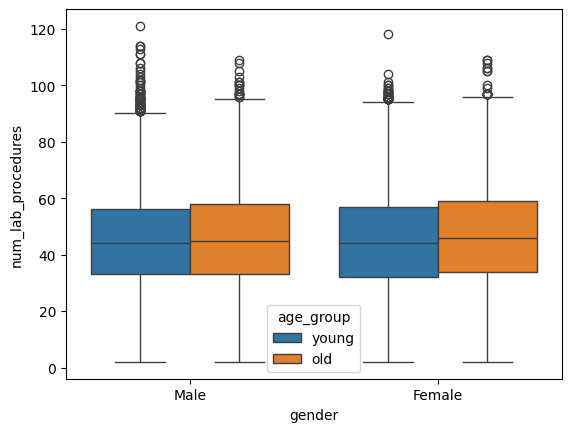

In [ ]:
print(data.groupby(['gender','age_group']).size())
print(data.groupby(['gender','age_group'])['num_lab_procedures'].describe())

sns.boxplot(data=data, x='gender', y='num_lab_procedures', hue='age_group')
plt.show()

Выборка несбалансирована по группам

---



предложение использовать Type III ANOVA

https://varmara.github.io/ru/post/2019-01-05-ss-type-iii-and-anova-parametrization/

При использовании SS type III значимость фактора проверяется по сравнению с моделью в которой есть другой фактор и взаимодействие SS(A | B, AB) и SS(B|A, AB). Статистики на это ругаются, потому что при таком способе нарушается принцип маргинальности (взаимодействие может входить в модель только если в ней есть все его составляющие). При таком способе расчета SS уже не зависит от численности групп, поэтому его часто рекомендуют использовать для несбалансированных данных.



2. Проверка на гомогенность дисперсий

Зависимая переменная: 'num_lab_procedures'

In [ ]:
from scipy.stats import levene
groups = []
groups.append(data[(data['gender'] == 'Female') & (data['age_group']== 'young')][ 'num_lab_procedures'])
groups.append(data[(data['gender'] == 'Female') & (data['age_group']== 'old')][ 'num_lab_procedures'])
groups.append(data[(data['gender'] == 'Male') & (data['age_group']== 'young')][ 'num_lab_procedures'])
groups.append(data[(data['gender'] == 'Male') & (data['age_group']== 'old')][ 'num_lab_procedures'])
levenes = []
stat, p_value = levene(*groups)
print(stat, round(p_value,5))
np.random.seed(42)
k=1000
for i in range(100):
  arr1 = np.random.permutation(groups[0])
  arr2 = np.random.permutation(groups[1])
  arr3 = np.random.permutation(groups[2])
  arr4 = np.random.permutation(groups[3])
  levenes.append(levene(arr1[:k], arr2[:k],arr3[:k],arr4[:k])[1])

print(sum(levenes)/len(levenes))

1.3583476987277638 0.25349
0.5151462018156684


p-value при 1 проходке равна 0.25>0.05 - дисперсия зависимой переменной гомогенна. А также если проверим в цикле, то в среднем p-value 0.51, что не может не радовать)

https://www.statisticshowto.com/homoscedasticity/

Если отношение наибольшей дисперсии к наименьшей дисперсии составляет 1,5 или меньше, данные являются гомоскедастическими.



3. Проверка на нормальное распределение в каждой группе

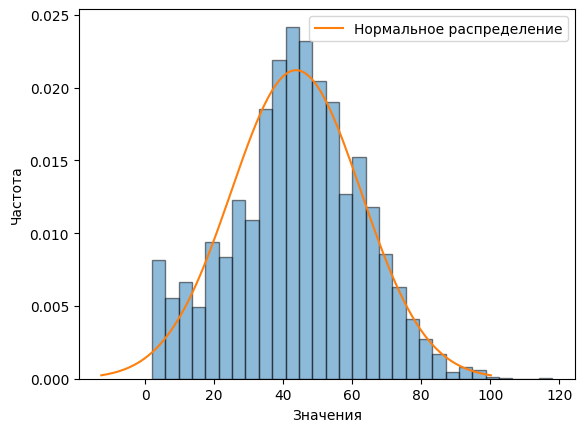

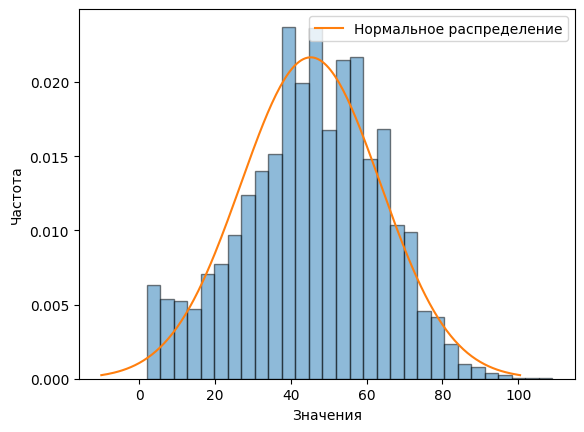

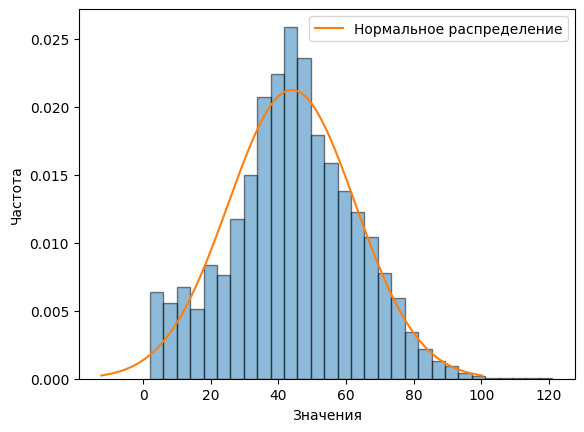

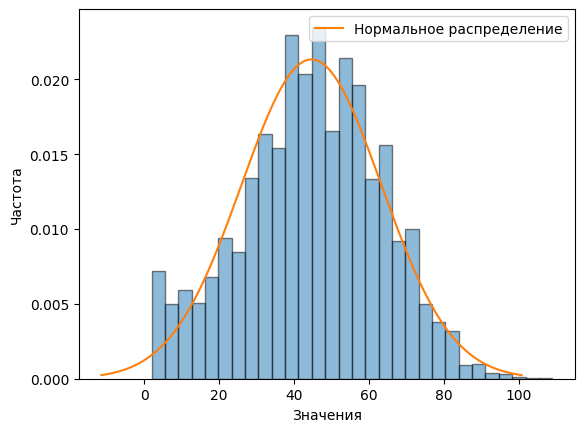

In [ ]:
from scipy.stats import norm

for group in groups:
    plt.hist(group, bins=30, edgecolor='black', alpha=0.5, density=True)
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    x = np.linspace(np.mean(group) - 3*np.std(group), np.mean(group) + 3*np.std(group), 200)
    y = norm.pdf(x,np.mean(group), np.std(group))
    plt.plot(x,y,label = "Нормальное распределение")
    plt.legend()
    plt.show()

визуально наши данные очень близки к нормальному распределению

Так как у нас много данных (больше 50, а именно 13-17 тыс в каждой группе), то ANOVA хорошо работает на приближенных к нормальности данным

https://pozdniakov.github.io/tidy_stats/350-anova.html
"
Как мы видим, распределение не сильно далеко от нормального - этого вполне достаточно. ANOVA - это метод достаточно устойчивый к отклонениям от нормальности."

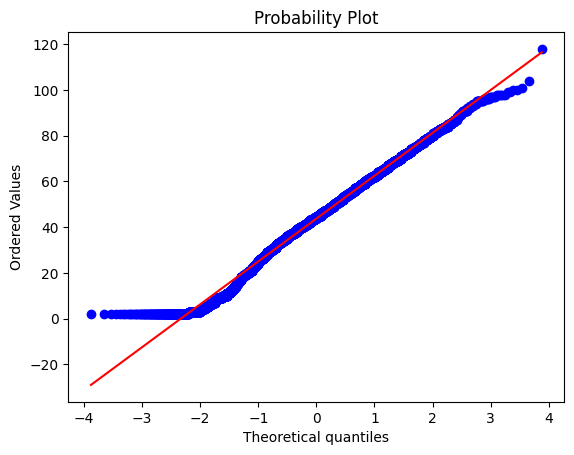

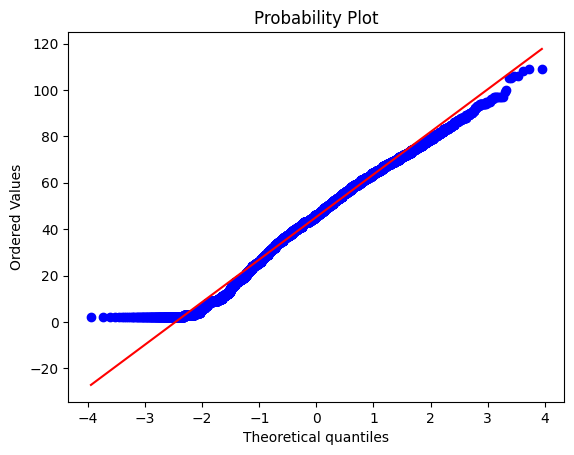

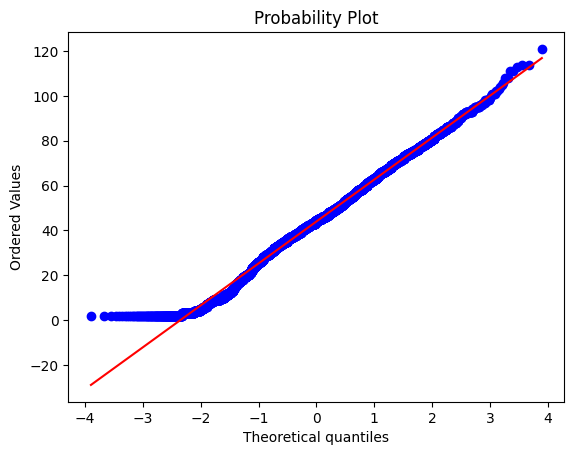

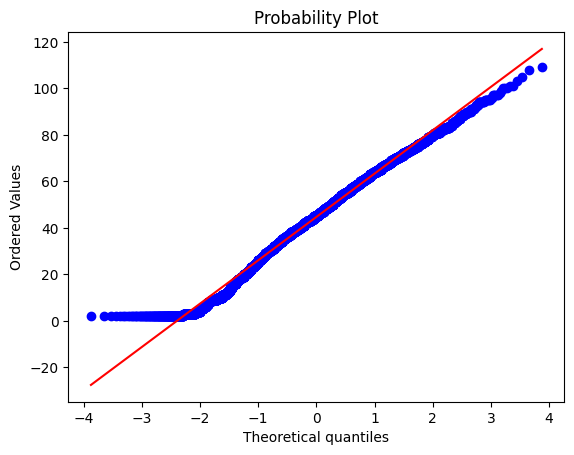

In [ ]:
for i in groups:
  stats.probplot(i, dist=stats.norm, plot=plt)
  plt.show()

наше распределение близко к нормальному, за исключением левого хвоста

In [ ]:
for group in groups:
  ks_statistic, ks_p_value = stats.kstest(group, 'norm', args=(group.mean(), group.std()))
  print(round(ks_statistic, 5), "p-value:", round(ks_p_value, 5))

0.03371 p-value: 0.0
0.03476 p-value: 0.0
0.03371 p-value: 0.0
0.03016 p-value: 0.0


Тест Колмогорова-Смирнова нам показал, что данные не распределены нормально. Для ANOVA важнее гомогенность дисперсий нежели нормальность распределения при большом количестве наблюдений. Но все равно нужно проверить насколько сильно на нас повлияет этот левый край, который присутствует у всех групп

# АА-тест

АА-тест поможет нам проверить не только на выход данных из одного распределения внутри групп, а также поможет проверить на влияние не нормального распределения данных в левом хвосте и работоспособность стат.критерия

В A/A тесте бутстрапом оценим доверительный интервал для ошибки 1го рода. Если значение находится в нем, значит, критерий валиден и группа однородна.

Будем использовать однофакторный дисперсионный анализ, так как проверяем данные внутри 1 группы (всего 1 фактор - отличаются ли средние двух случайных подгрупп одной и той же генеральной совокупности). Логика такова: делим нашу группу на две с одинаковым кол-вом данных на рандом, проводим однофакторный ANOVA, смотрим на распределение p-value и доверительный интервал

In [ ]:
def ci(
    pvalue_vector: np.array,
    alpha=0.05
) -> tuple[float, float, float]:
    n = len(pvalue_vector)
    n_critical = np.sum(pvalue_vector <= alpha)
    p = n_critical / n
    var = p * (1 - p) / n
    scale = stats.norm.ppf(1-alpha/2)
    eps = np.sqrt(var) * scale
    left_bound = p - eps
    right_bound = p + eps
    return p, left_bound, right_bound


def ks_uniformity_check(
    pvalue_vector: np.ndarray,
):
    n = len(pvalue_vector)
    sorted_pvals = np.sort(pvalue_vector)
    theoretical_cdf = sorted_pvals

    d_plus  = np.max(np.arange(1, n + 1) / n - theoretical_cdf)
    d_minus = np.max(theoretical_cdf - np.arange(0, n) / n)

    print(d_plus.shape)

    D_n = max(d_plus, d_minus)
    lam = np.sqrt(n) * D_n

    p_value = 2 * sum(
        ((-1) ** (k - 1)) * np.exp(-2 * k**2 * lam**2)
        for k in range(1, 100)
    )
    p_value = np.clip(p_value, 0, 1)

    # ks_stat, ks_pval = stats.kstest(pvalue_vector, 'uniform', args=(0, 1))
    # assert np.isclose(D_n, ks_stat, atol=1e-6) \
    #        and np.isclose(ks_pval, p_value, atol=1e-2), f"something went wrong {D_n, ks_stat, p_value, ks_pval}"

    return D_n, p_value
def plot_comparison_with_uniform(
    pvalue_vector: list,
    title: str,
    aplha=0.05,
    color='orange'
):
    pvalue_vector = np.array(pvalue_vector)
    n = len(pvalue_vector)
    p, left_boundary, right_boundary = ci(pvalue_vector, aplha)
    print(f"Ошибка I рода: {round(p, 4)},\nCI для oшибки I рода: [{round(left_boundary, 4)}, {round(right_boundary, 4)}]")

    _, ax1 = plt.subplots(1, 3, figsize=(17, 5))

    # Гистограмма P-value
    ax1[0].hist(pvalue_vector, bins=30, edgecolor='black', alpha=0.6, color=color)
    ax1[0].set_title(
        f'распределение P-value'
    )
    ax1[0].set_xlabel('P-value')
    ax1[0].set_ylabel('Частота')

    # QQ-график
    stats.probplot(pvalue_vector, dist=stats.uniform, plot=ax1[1])
    ax1[1].get_lines()[1].set_linestyle('--')
    ax1[1].set_title(f'{title} (QQ-график)')

    # Эмпирическая функция распределения
    sorted_pvalue_vector = sorted(pvalue_vector)
    ordinal_positions = np.arange(1, n+1) / n
    x_uniform = np.linspace(0, 1, 100)
    cdf_uniform = x_uniform

    ax1[2].step(sorted_pvalue_vector, ordinal_positions, where='post', label='Эмпирическая ФР', color=color)
    ax1[2].plot(x_uniform, cdf_uniform, 'k--', label='Теоретическая CDF $U[0,1]$')
    ax1[2].set_title('Эмпирическая и теоретическая ФР')
    ax1[2].set_xlabel('p-value')
    ax1[2].set_ylabel('dist(p-value)')

    # Тест Колмогорова-Смирнова
    ks_statistic, ks_p_value = ks_uniformity_check(pvalue_vector)
    print(f'Статистика Колмогорова-Смирнова: {round(ks_statistic, 4)}, pvalue для сравнения ЭФР с равномерным: {round(ks_p_value, 4)}')
    if ks_p_value < 0.05:
        print("Гипотеза H0 отвергается: выборка НЕ из равномерного U(0,1)")
    else:
        print("Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)")

    ax1[2].text(
        0.05, 0.9,
        f"KS: stat={ks_statistic:.3f}\np={ks_p_value:.3f}",
        fontsize=10,
        verticalalignment='top',
        bbox={"boxstyle": "round", "facecolor": "w"}
    )
    plt.tight_layout()
    plt.show()


def ANOVA1(x_num, y_num):
 # arr = np.random.permutation(group)
 # s1 = arr[0:len(group)//2]
#  s2 = arr[len(group)//2:]
  s1 = x_num
  s2 = y_num
  mean1 = sum(s1)/len(s1)
  mean2 = sum(s2)/len(s2)
  meanTotal = sum(arr)/len(arr)
  SSB = 0
  SSB = len(s1)* (mean1-meanTotal)**2 + len(s2)* (mean2-meanTotal)**2
  SSW = 0
  for k in s1:
    SSW+=(k-mean1)**2
  for k in s2:
    SSW+=(k-mean2)**2
  DFB = 2-1 #two groups - 1
  DFW = len(group) - 2
  MSB = SSB/DFB
  MSW = SSW/DFW
  F = MSB/MSW
  return F, 1 - stats.f.cdf(F, DFB, DFW)


def student_ttest(test_event: np.ndarray, control_event: np.ndarray) -> tuple[float, float]:
    n1, n2 = len(test_event), len(control_event)
    df = n1 + n2 - 2
    mean1, mean2 = np.mean(test_event), np.mean(control_event)

    var1 = np.sum((test_event - mean1)**2) / (n1 - 1)
    var2 = np.sum((control_event - mean2)**2) / (n2 - 1)
    var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)

    t_stat = (mean1 - mean2) / np.sqrt(var * (1/n1 + 1/n2))
    p_value = betainc(df / 2, 0.5, df / (df + t_stat**2))

    # ts, tpval = stats.ttest_ind(test_event, control_event)
    # assert np.isclose(t_stat, ts) and np.isclose(tpval, p_value), f"{t_stat, ts, tpval, p_value}"
    return t_stat, p_value

In [ ]:
pvalue = []
for i in range (1,1000):
    arr = np.random.permutation(groups[0])
    s1 = arr[0:len(groups[0])//2]
    s2 = arr[len(groups[0])//2:]
    _, p_value = ANOVA1(s1, s2)
    pvalue.append(p_value)

Ошибка I рода: 0.049,
CI для oшибки I рода: [0.0357, 0.0624]
()
Статистика Колмогорова-Смирнова: 0.0235, pvalue для сравнения ЭФР с равномерным: 0.6419
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


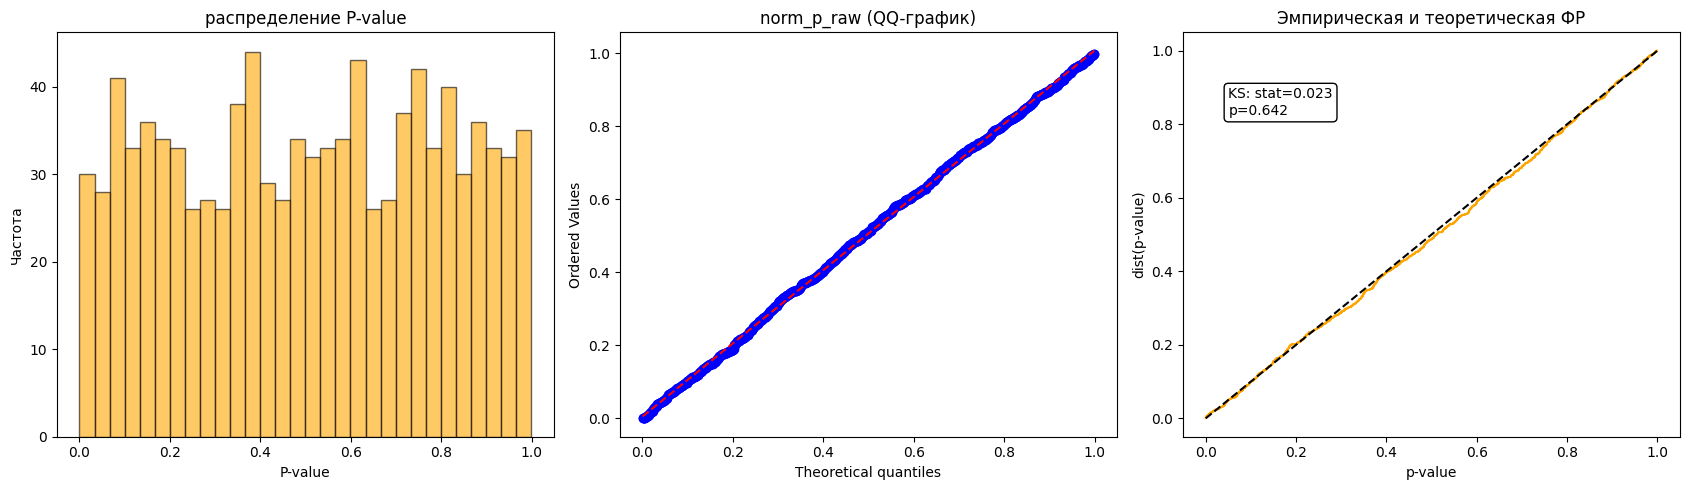

In [ ]:
plot_comparison_with_uniform(pvalue, "norm_p_raw")

Ошибка I рода: 0.021,
CI для oшибки I рода: [0.0121, 0.0299]
()
Статистика Колмогорова-Смирнова: 0.0733, pvalue для сравнения ЭФР с равномерным: 0.0
Гипотеза H0 отвергается: выборка НЕ из равномерного U(0,1)


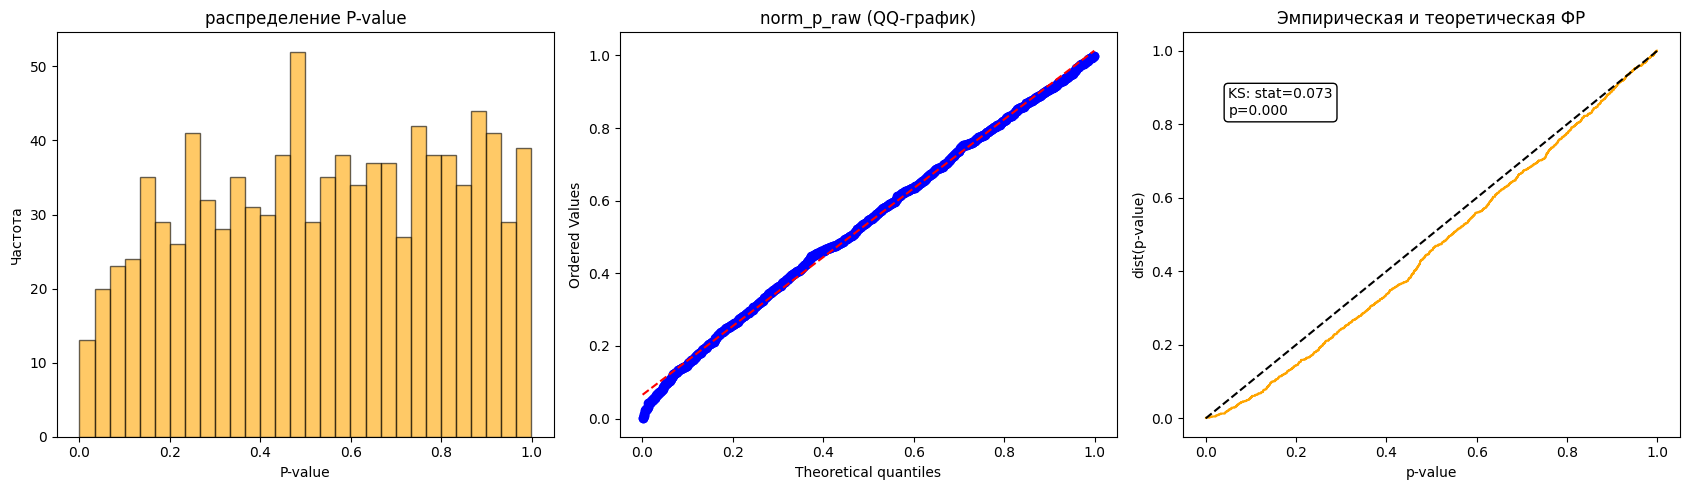

In [ ]:
pvalue = []
for i in range (1,1000):
    arr = np.random.permutation(groups[1])
    s1 = arr[0:len(groups[1])//2]
    s2 = arr[len(groups[1])//2:]
    _, p_value = ANOVA1(s1, s2)
    pvalue.append(p_value)
plot_comparison_with_uniform(pvalue, "norm_p_raw")

Ошибка I рода: 0.043,
CI для oшибки I рода: [0.0305, 0.0556]
()
Статистика Колмогорова-Смирнова: 0.0266, pvalue для сравнения ЭФР с равномерным: 0.4787
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


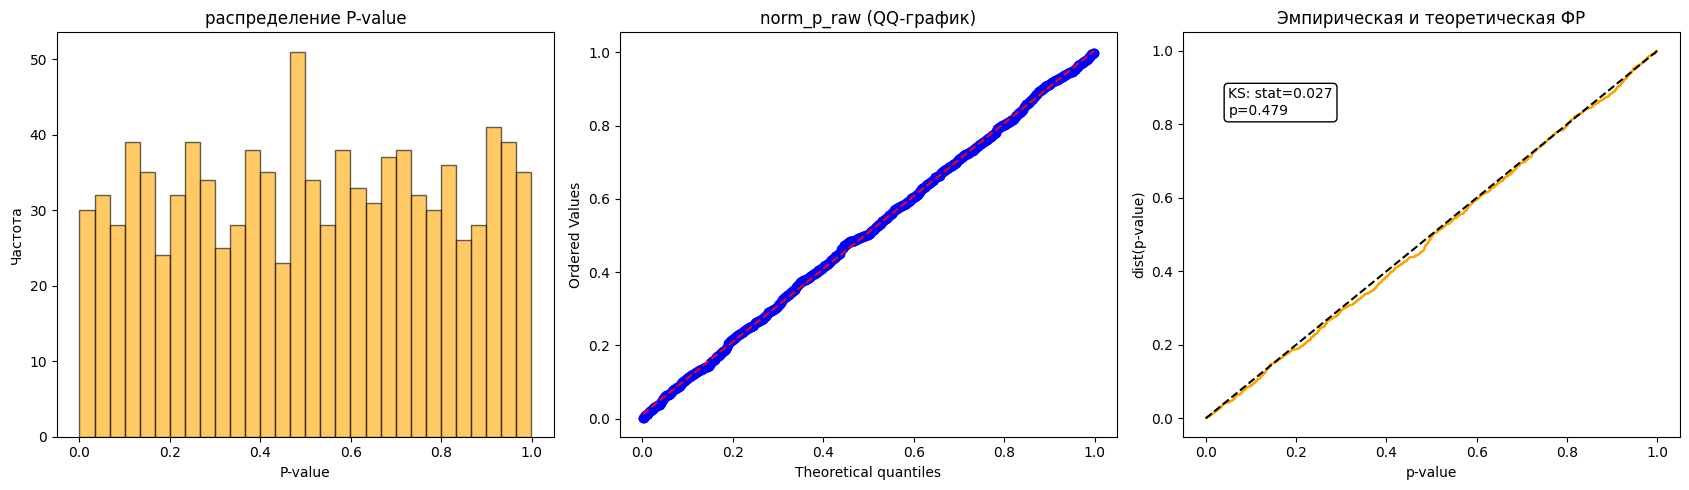

In [ ]:
pvalue = []
for i in range (1,1000):
    arr = np.random.permutation(groups[2])
    s1 = arr[0:len(groups[2])//2]
    s2 = arr[len(groups[2])//2:]
    _, p_value = ANOVA1(s1, s2)
    pvalue.append(p_value)
plot_comparison_with_uniform(pvalue, "norm_p_raw")

Ошибка I рода: 0.0611,
CI для oшибки I рода: [0.0462, 0.0759]
()
Статистика Колмогорова-Смирнова: 0.0229, pvalue для сравнения ЭФР с равномерным: 0.6726
Нет оснований отвергнуть H0: выборка МОГЛА быть из U(0,1)


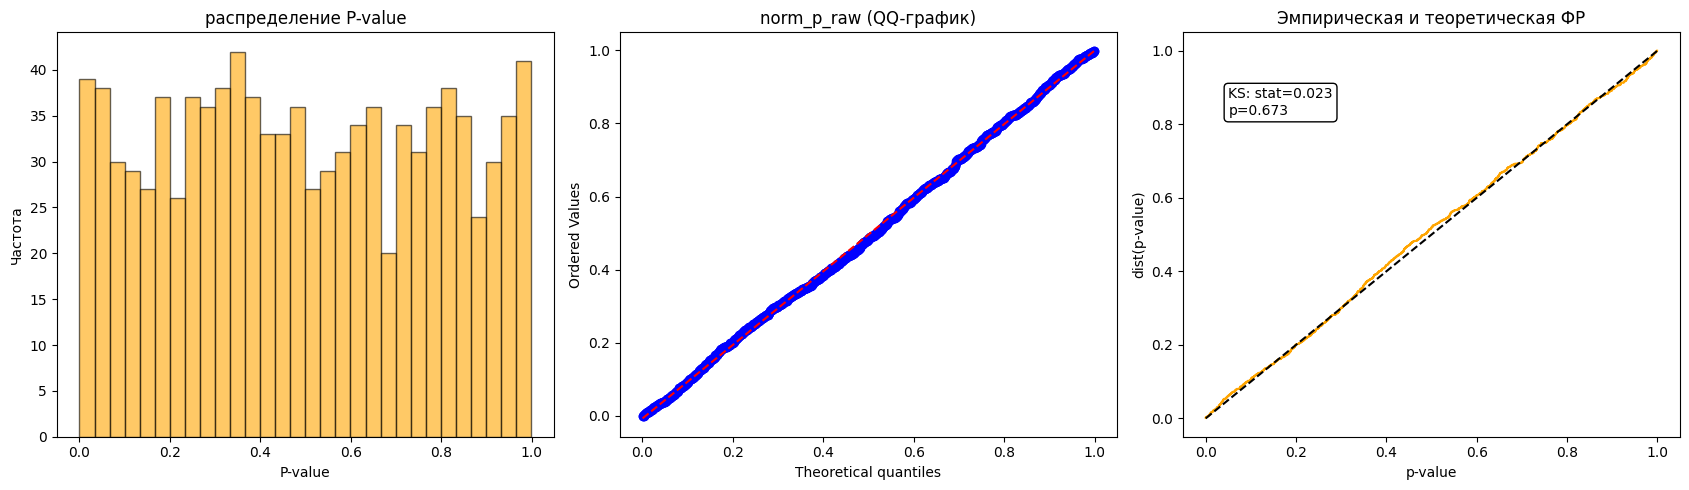

In [ ]:
pvalue = []
for i in range (1,1000):
    arr = np.random.permutation(groups[3])
    s1 = arr[0:len(groups[3])//2]
    s2 = arr[len(groups[3])//2:]
    _, p_value = ANOVA1(s1, s2)
    pvalue.append(p_value)
plot_comparison_with_uniform(pvalue, "norm_p_raw")

Видим, что в 3 из 4 групп p-value распределено равномерно. Только в одной все не идеально, но визуально видим, особенно на QQ плоте, что данные сильно приближены к равномерному распределению. Так как у нас количество наблюдений в каждой из групп очень большое, то мы можем спокойно проводить анализ, так как ANOVA на большом количестве данных достаточно устройчива к неидеальности выполнения критериев

# АБ тест

Переходим к АБ тестированию. У нас два фактора: возраст и пол, поэтому будем использовать двухфакторный дисперсионный анализ. Из-за дисбаланса групп нам лучше подходит 3 Тип ановы, но мы посмотрим и на 2 тип тоже.

Сначала посмотрим на результаты двухфакторного дисперсионного анализа 2 Типа

Type 2 проверяет фактор после учёта остальных факторов, но без взаимодействия
(условно gender ∣ age_group)

Сначала учитываем возраст, потом проверяем пол, при этом взаимодействие фактически игнорируется

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
data_anova2 = data[['gender', 'age_group', 'num_lab_procedures']].copy()
args = ols('num_lab_procedures ~ gender * age_group', data=data_anova2).fit()
anova_table = sm.stats.anova_lm(args,test = "F", typ=2)
anova_table['sum_sq'] = anova_table['sum_sq'].round(0)
anova_table['PR(>F)'] = anova_table['PR(>F)'].round(5)
print(anova_table)

                      sum_sq       df          F   PR(>F)
gender                 478.0      1.0   1.372235  0.24143
age_group            18896.0      1.0  54.249761  0.00000
gender:age_group      2196.0      1.0   6.304759  0.01204
Residual          20301787.0  58286.0        NaN      NaN


влияние фактора  Пола нет, HOa подтвердилась

влияние фактора Вораста есть, HOв опроверглась

влияние обоих факторов есть, НОав опроверглась

Теперь посмотрим на тип 3, который нам подходит больше из-за неравномерности групп


Type 3 проверяет каждый эффект после учёта всех остальных (gender ∣ age_group+gender:age_group)

пример для типа 3: сравниваем пол Женский со средним человеком (средний среди мужчин и женщин)

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
data_anova2 = data[['gender', 'age_group', 'num_lab_procedures']].copy()
args = ols('num_lab_procedures ~ C(gender, Sum)*C(age_group, Sum)', data=data_anova2).fit()
anova_table = sm.stats.anova_lm(args,test = "F", typ=3)
anova_table['sum_sq'] = anova_table['sum_sq'].round(0)
anova_table['PR(>F)'] = anova_table['PR(>F)'].round(5)
print(anova_table)

                                       sum_sq       df              F   PR(>F)
Intercept                         113400970.0      1.0  325571.777042  0.00000
C(gender, Sum)                          385.0      1.0       1.105985  0.29296
C(age_group, Sum)                     18159.0      1.0      52.135141  0.00000
C(gender, Sum):C(age_group, Sum)       2196.0      1.0       6.304759  0.01204
Residual                           20301787.0  58286.0            NaN      NaN


Type 3 смотрит на: нужен ли фактор после учета всех остальных эффектов.

Для этого модель должна использовать способ кодирования категории, где коэффициенты интерпретируются относительно общего среднего. Именно по этому добавляем SUM

Видим аналогичный результат!!!

ИТОГ:
Есть статистически значимое влияние возраста и возраста+пола на кол-во процедур, которые проводятся над пациентами больницы.

Давайте посмотрим на уровень влияния:

In [ ]:
ss_error = anova_table.loc['Residual', 'sum_sq']
anova_table['Уровень влияния в %'] = (anova_table['sum_sq'] /(anova_table['sum_sq'] + ss_error))*100

anova_table.loc[['C(gender, Sum)', 'C(age_group, Sum)','C(gender, Sum):C(age_group, Sum)']]

20301787.0


,sum_sq,df,F,PR(>F),Уровень влияния в %
"C(gender, Sum)",385.0,1.0,1.105985,0.29296,0.001896
"C(age_group, Sum)",18159.0,1.0,52.135141,0.00000,0.089365
"C(gender, Sum):C(age_group, Sum)",2196.0,1.0,6.304759,0.01204,0.010816


Хоть мы и выявили наличие статистически значимого влияния двух факторов на зависимую переменную, в процентах оно очень маленькое: в обоих случаях меньше 0,1%, что для нас не значимо в рамках бизнес кейса

Поэтому результаты нашего анализа таковы: пол и возраст не имеет значимого влияния на количество медицинских процедур у пациента, а значит мы не учитываем эти факторы в нашем кейсе